# ASR Pipeline Visualizer + Multi-Model Comparison — Python notebook

Mirrors the web app (`index.html`):

1. Load audio → frames / windows / FFT / **80-bin log-mel spectrogram** (16 kHz, 25 ms window, 10 ms hop, 512-pt FFT).
2. Plots: waveform, full mel-spectrogram, single-window deep dive (slice, Hann, padded FFT, log-mel, mel filterbank).
3. Energy **VAD** → speech chunks.
4. Transcribe with several models — **OpenAI** & **Gemini** (API) and **HuggingFace Whisper running locally** via `transformers` (no API call).
5. Score **WER** with substitutions / insertions / deletions vs a ground-truth reference, plus latency & estimated cost.


## 0 · Install (run once)

In [1]:
# Core DSP/plots + WER + local HF inference. Uncomment to install.
# %pip install -q numpy scipy matplotlib librosa soundfile jiwer pandas
# %pip install -q transformers torch            # local HuggingFace Whisper (no API)


## 1 · Config — set your audio file and ground truth (all models run locally, no keys)

In [2]:
import os

SR          = 16000           # everything runs at 16 kHz mono (Whisper's rate)
FRAME_MS    = 20              # VAD frame size (non-overlapping)
WIN         = 400             # 25 ms analysis window
HOP         = 160             # 10 ms hop
N_FFT       = 512
N_MELS      = 80
FMIN, FMAX  = 0, 8000
VAD_MULT    = 8              # threshold = 8 x noise floor
SILENCE_TAIL_MS = 600        # gap shorter than this stays inside a chunk

MODELS_DIR  = 'models'        # local HF weights live here, bundled next to this notebook
AUDIO_PATH  = 'sample.wav'    # <-- point this at your clip (wav/mp3/m4a/flac)
GROUND_TRUTH = 'The quick brown fox jumps over the lazy dog while the morning train departs from platform nine.'  # macOS 'say' sample (cell auto-set for the verification run)

# Which models to compare — all run locally on your machine, no API keys, no downloads.
MODELS = [
    # --- local HuggingFace models (run on your machine, no API key) ---
    'local:openai/whisper-tiny.en',            # Whisper (OpenAI) · English
    'local:openai/whisper-base',               # Whisper (OpenAI) · multilingual
    'local:openai/whisper-small',              # Whisper (OpenAI) · multilingual
    'local:distil-whisper/distil-small.en',    # distil-Whisper (HuggingFace) · faster
    'local:UsefulSensors/moonshine-base',      # Moonshine (Useful Sensors) · tiny & fast
    'local:facebook/wav2vec2-base-960h',       # wav2vec2 (Meta) · CTC
    # NVIDIA Parakeet / Canary need NeMo — see the optional NeMo cell near the end.
]


## 1b · Bundle the local models into `./models/` (so the repo is self-contained)

Downloads each `local:*` Whisper model into `MODELS_DIR` once. Commit that folder (via Git LFS) so anyone who clones the repo can run offline. If the folder is missing, `transcribe_local` falls back to downloading from the Hugging Face hub automatically.

In [3]:
import os
from huggingface_hub import snapshot_download

os.makedirs(MODELS_DIR, exist_ok=True)
for spec in MODELS:
    kind, mid = spec.split(':', 1)
    if kind != 'local':
        continue
    dest = os.path.join(MODELS_DIR, mid.split('/')[-1])
    if os.path.isdir(dest) and os.listdir(dest):
        print('already bundled:', dest); continue
    print('downloading', mid, '->', dest)
    snapshot_download(repo_id=mid, local_dir=dest,
                      allow_patterns=['*.json','*.txt','*.safetensors','vocab*','merges*','*.model'])
print('local models ready in', os.path.abspath(MODELS_DIR))

already bundled: models/whisper-tiny.en
already bundled: models/whisper-base
already bundled: models/whisper-small
already bundled: models/distil-small.en
already bundled: models/moonshine-base
already bundled: models/wav2vec2-base-960h
local models ready in /Users/ankitmishra/Desktop/Desktop/Ankit/Desktop/IMMI/TU-JOB/TU_work/Perception/asr-pipeline-visualizer/models


/Users/ankitmishra/Desktop/Desktop/Ankit/Desktop/IMMI/TU-JOB/TU_work/Perception/asr/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2 · Load audio (decode + resample to 16 kHz mono)

In [4]:
import numpy as np, librosa

audio, _ = librosa.load(AUDIO_PATH, sr=SR, mono=True)
audio = audio.astype(np.float32)
dur = len(audio) / SR
print(f'Loaded {AUDIO_PATH}: {len(audio):,} samples, {dur:.2f} s @ {SR} Hz')


Loaded sample.wav: 81,556 samples, 5.10 s @ 16000 Hz


## 3 · Pipeline shapes (what your audio became)

In [5]:
frame_len = round(FRAME_MS/1000*SR)
n_frames  = len(audio)//frame_len
n_windows = 1 + (len(audio)-WIN)//HOP

print(f'audio:       {len(audio):,} samples (float32)  // {dur:.2f}s x {SR} Hz')
print(f'frames:      {n_frames:,} x {FRAME_MS} ms       // VAD speech/silence unit')
print(f'windows:     {n_windows:,} x 25 ms             // 10 ms hop -> spectrogram columns')
print(f'per window:  400 samples -> 512 padded -> 257 FFT mags -> 80 log-mel')
print(f'spectrogram: 80 x {n_windows:,} log-mel matrix  // the Whisper encoder input')


audio:       81,556 samples (float32)  // 5.10s x 16000 Hz
frames:      254 x 20 ms       // VAD speech/silence unit
windows:     508 x 25 ms             // 10 ms hop -> spectrogram columns
per window:  400 samples -> 512 padded -> 257 FFT mags -> 80 log-mel
spectrogram: 80 x 508 log-mel matrix  // the Whisper encoder input


## 4 · DSP — FFT, mel filterbank, log-mel spectrogram (matches the web app)

In [6]:
hann = np.hanning(WIN).astype(np.float32)

def hz_to_mel(f): return 2595*np.log10(1+f/700)
def mel_to_hz(m): return 700*(10**(m/2595)-1)

# 80 triangular mel filters over the 257 FFT bins (0-8 kHz)
BINS = N_FFT//2 + 1
mel_pts = mel_to_hz(np.linspace(hz_to_mel(FMIN), hz_to_mel(FMAX), N_MELS+2))
bin_hz  = np.arange(BINS)*SR/N_FFT
mel_fb  = np.zeros((N_MELS, BINS), np.float32)
for m in range(1, N_MELS+1):
    lo, ctr, hi = mel_pts[m-1], mel_pts[m], mel_pts[m+1]
    for k in range(BINS):
        f = bin_hz[k]
        if   lo <= f <= ctr: mel_fb[m-1,k] = (f-lo)/(ctr-lo or 1)
        elif ctr < f <= hi:  mel_fb[m-1,k] = (hi-f)/(hi-ctr or 1)

def window_slice(off):
    s = np.zeros(WIN, np.float32); seg = audio[off:off+WIN]; s[:len(seg)] = seg
    return s
def fft_mag(off):
    padded = np.zeros(N_FFT, np.float32); padded[:WIN] = window_slice(off)*hann
    return np.abs(np.fft.rfft(padded))
def log_mel_col(off):
    mag = fft_mag(off)
    return np.log(np.maximum(mel_fb @ (mag**2), 1e-10))

offsets = np.arange(n_windows)*HOP
spec = np.stack([log_mel_col(o) for o in offsets], axis=1)   # (80, n_windows)
print('spectrogram shape:', spec.shape)


spectrogram shape: (80, 508)


## 5 · Plots — waveform + full mel spectrogram

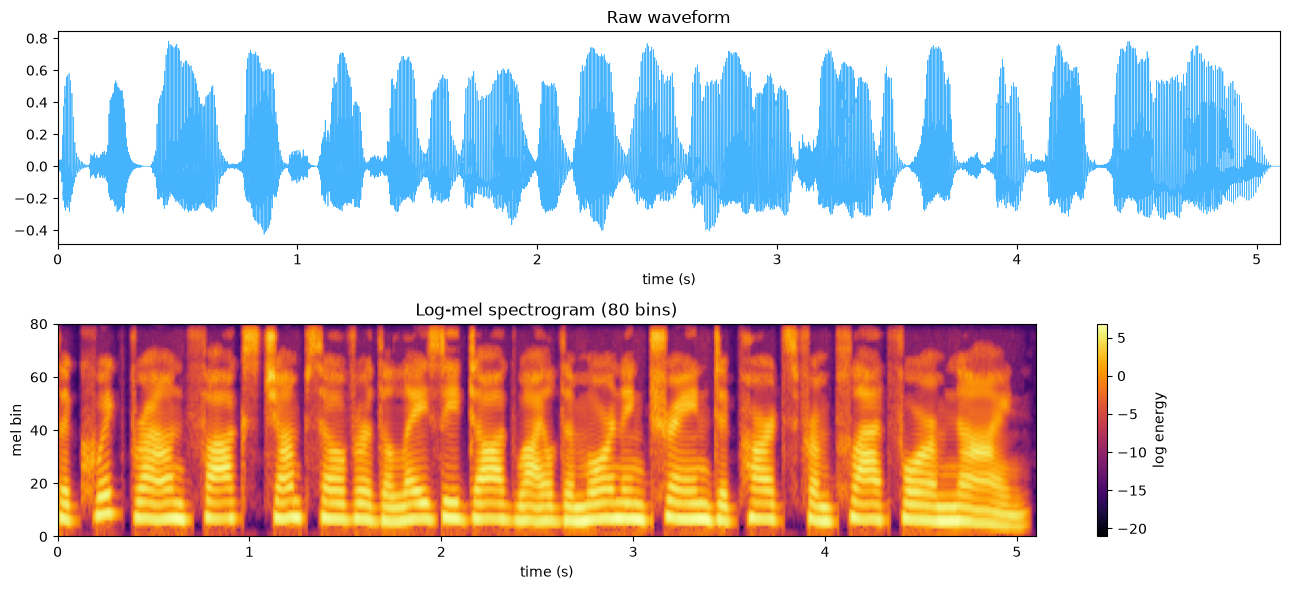

In [7]:
import matplotlib.pyplot as plt

t = np.arange(len(audio))/SR
fig, ax = plt.subplots(2, 1, figsize=(13, 6))
ax[0].plot(t, audio, lw=0.5, color='#46b3ff'); ax[0].set_title('Raw waveform')
ax[0].set_xlabel('time (s)'); ax[0].set_xlim(0, dur)
im = ax[1].imshow(spec, origin='lower', aspect='auto', cmap='inferno',
                  extent=[0, dur, 0, N_MELS])
ax[1].set_title('Log-mel spectrogram (80 bins)'); ax[1].set_xlabel('time (s)'); ax[1].set_ylabel('mel bin')
fig.colorbar(im, ax=ax[1], label='log energy'); plt.tight_layout(); plt.show()


## 6 · Selected-window deep dive (pick a window index)

window 335/508  (3.340-3.365 s)


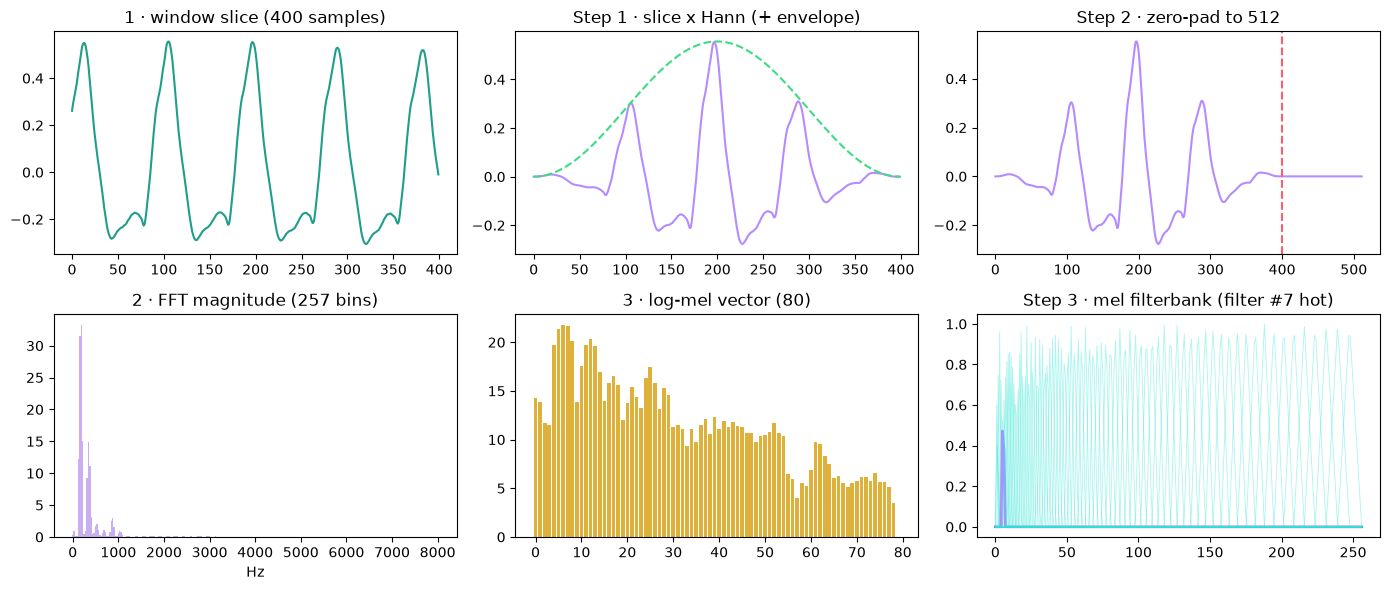

In [8]:
# Default to the loudest window
energies = np.array([np.sum(window_slice(o)**2) for o in offsets])
WIN_IDX  = int(np.argmax(energies))
off = WIN_IDX*HOP
print(f'window {WIN_IDX+1}/{n_windows}  ({off/SR:.3f}-{(off+WIN)/SR:.3f} s)')

sl  = window_slice(off); mag = fft_mag(off); lm = log_mel_col(off)
hi  = int(np.argmax(lm))
fig, ax = plt.subplots(2, 3, figsize=(14, 6))
ax[0,0].plot(sl, color='#1f9e8a'); ax[0,0].set_title('1 · window slice (400 samples)')
ax[0,1].plot(sl*hann, color='#b58cff'); ax[0,1].plot(hann*np.max(np.abs(sl)), '--', color='#3ddc84')
ax[0,1].set_title('Step 1 · slice x Hann (+ envelope)')
padded = np.zeros(N_FFT); padded[:WIN] = sl*hann
ax[0,2].plot(padded, color='#b58cff'); ax[0,2].axvline(WIN, ls='--', color='#ff5c6c')
ax[0,2].set_title('Step 2 · zero-pad to 512')
ax[1,0].bar(np.arange(BINS)*SR/N_FFT, mag, width=SR/N_FFT, color='#c9aef0')
ax[1,0].set_title('2 · FFT magnitude (257 bins)'); ax[1,0].set_xlabel('Hz')
ax[1,1].bar(range(N_MELS), lm-lm.min(), color='#e0b13a'); ax[1,1].set_title('3 · log-mel vector (80)')
for m in range(N_MELS):
    ax[1,2].plot(mel_fb[m], color=('#b58cff' if m==hi else '#2ee6d6'), lw=(2 if m==hi else 0.6), alpha=(1 if m==hi else 0.4))
ax[1,2].set_title(f'Step 3 · mel filterbank (filter #{hi+1} hot)')
plt.tight_layout(); plt.show()


## 7 · Voice Activity Detection → chunks

0 chunk(s):


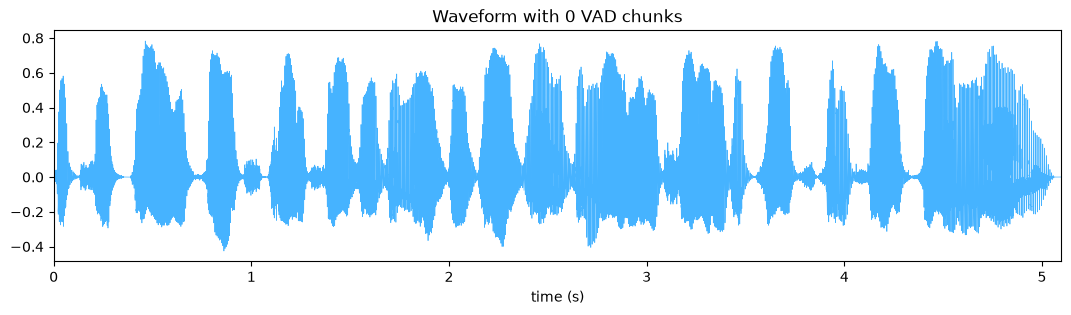

In [9]:
def run_vad(sig):
    nF = len(sig)//frame_len
    en = np.array([np.sqrt(np.mean(sig[w*frame_len:(w+1)*frame_len]**2)) for w in range(nF)])
    noise = np.sort(en)[int(len(en)*0.2)] if len(en) else 1e-4
    thr = max(noise*VAD_MULT, 1e-3)
    speech = en > thr
    tailF = int(np.ceil(SILENCE_TAIL_MS/1000*SR/frame_len))
    w = 0
    while w < nF:
        if not speech[w]:
            k = w
            while k < nF and not speech[k]: k += 1
            if (k-w) <= tailF and w > 0 and k < nF: speech[w:k] = True
            w = k
        else: w += 1
    segs, s = [], -1
    for w in range(nF):
        if speech[w] and s < 0: s = w
        if (not speech[w] or w == nF-1) and s >= 0:
            e = w+1 if speech[w] else w; segs.append((s*frame_len, e*frame_len)); s = -1
    return segs, speech

chunks, speech = run_vad(audio)
print(f'{len(chunks)} chunk(s):')
for i,(a,b) in enumerate(chunks): print(f'  chunk {i+1}: {a/SR:.2f}-{b/SR:.2f} s')

plt.figure(figsize=(13,3)); plt.plot(t, audio, lw=0.5, color='#46b3ff')
for a,b in chunks: plt.axvspan(a/SR, b/SR, color='#ff5c6c', alpha=0.15)
plt.title(f'Waveform with {len(chunks)} VAD chunks'); plt.xlabel('time (s)'); plt.xlim(0,dur); plt.show()


## 8 · WER helper (substitutions / insertions / deletions via jiwer)

In [10]:
import jiwer

_norm = jiwer.Compose([
    jiwer.ToLowerCase(), jiwer.RemovePunctuation(),
    jiwer.RemoveMultipleSpaces(), jiwer.Strip(), jiwer.ReduceToListOfListOfWords(),
])

def score(ref, hyp):
    if not ref.strip():
        return None
    out = jiwer.process_words(ref, hyp, reference_transform=_norm, hypothesis_transform=_norm)
    return dict(wer=out.wer, S=out.substitutions, I=out.insertions, D=out.deletions, H=out.hits, _out=out)


## 9 · Transcribers — local HuggingFace models (no API, no keys)

In [11]:
_local_cache = {}
def transcribe_local(model_id):
    '''Runs HuggingFace Whisper on THIS machine — no API call.
    Loads from the bundled ./models/<name> folder if present, else downloads from the hub.'''
    from transformers import pipeline
    local = os.path.join(MODELS_DIR, model_id.split('/')[-1])
    src = local if (os.path.isdir(local) and os.listdir(local)) else model_id
    if model_id not in _local_cache:
        _local_cache[model_id] = pipeline('automatic-speech-recognition', model=src)
    pipe = _local_cache[model_id]
    try:                       # Whisper-family supports long-form chunking
        out = pipe(AUDIO_PATH, chunk_length_s=30, stride_length_s=5)
    except Exception:          # wav2vec2 / moonshine don't take these kwargs
        out = pipe(AUDIO_PATH)
    return out['text'].strip()

def dispatch(spec):
    kind, model_id = spec.split(':', 1)
    if kind == 'local': return transcribe_local(model_id)
    raise ValueError('unknown kind '+kind)

def est_cost(spec, text):
    return 0.0   # everything runs locally — no API cost


## 10 · Run the comparison

In [12]:
import time, pandas as pd

rows = []
for spec in MODELS:
    t0 = time.time()
    try:
        text = dispatch(spec); err = None
    except Exception as e:
        text, err = '', str(e)
    lat = (time.time()-t0)*1000
    sc = score(GROUND_TRUTH, text) if (text and not err) else None
    rows.append({
        'model': spec, 'latency_ms': round(lat),
        'cost_usd': round(est_cost(spec, text), 6) if not err else None,
        'WER_%': round(sc['wer']*100, 1) if sc else None,
        'Sub': sc['S'] if sc else None, 'Ins': sc['I'] if sc else None, 'Del': sc['D'] if sc else None,
        'transcript': (err and 'ERROR: '+err) or text,
    })
    print(('FAIL ' if err else 'ok   ')+spec+('  '+err if err else f"  {lat:.0f}ms  WER={sc['wer']*100:.1f}%" if sc else f'  {lat:.0f}ms'))

df = pd.DataFrame(rows)
df_sorted = df.sort_values('WER_%', na_position='last') if df['WER_%'].notna().any() else df
df_sorted


Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 167/167 [00:00<00:00, 6597.12it/s]

[transformers] Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.


[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.


...

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 6826.81it/s]


[transformers] Wav2Vec2ForCTC LOAD REPORT from: models/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ok   local:facebook/wav2vec2-base-960h  1926ms  WER=0.0%


,model,latency_ms,cost_usd,WER_%,Sub,Ins,Del,transcript
5,local:facebook/wav2vec2-base-960h,1926,0.0,0.0,0,0,0,THE QUICK BROWN FOX JUMPS OVER THE LAZY DOG WH...
1,local:openai/whisper-base,2250,0.0,5.9,1,0,0,The quick brown fox jumps over the lazy dog wh...
2,local:openai/whisper-small,6357,0.0,5.9,1,0,0,The quick brown fox jumps over the lazy dog wh...
3,local:distil-whisper/distil-small.en,2078,0.0,5.9,1,0,0,The quick brown fox jumps over the lazy dog wh...
4,local:UsefulSensors/moonshine-base,1638,0.0,5.9,1,0,0,The quick brown fox jumps over the lazy dog wh...
0,local:openai/whisper-tiny.en,6754,0.0,11.8,1,0,1,quick brown fox jumps over the lazy dog while ...


## 11 · Alignment view for one model (color-coded S / I / D)

In [13]:
PICK = MODELS[0]                       # change to any model spec above
row = next(r for r in rows if r['model'] == PICK)
print('MODEL :', PICK)
print('HYP   :', row['transcript'][:400])
sc = score(GROUND_TRUTH, row['transcript']) if GROUND_TRUTH.strip() else None
if sc:
    print(f"\nWER={sc['wer']*100:.1f}%  S={sc['S']} I={sc['I']} D={sc['D']} (correct={sc['H']})\n")
    print(jiwer.visualize_alignment(sc['_out']))   # S=substitution, I=insertion, D=deletion
else:
    print('\n(Set GROUND_TRUTH in cell 1 to see WER alignment.)')


MODEL : local:openai/whisper-tiny.en
HYP   : quick brown fox jumps over the lazy dog while the morning train departs from platform 9.

WER=11.8%  S=1 I=0 D=1 (correct=15)

=== SENTENCE 1 ===

REF: the quick brown fox jumps over the lazy dog while the morning train departs from platform nine
HYP: *** quick brown fox jumps over the lazy dog while the morning train departs from platform    9
       D                                                                                          S

=== SUMMARY ===
number of sentences: 1
substitutions=1 deletions=1 insertions=0 hits=15

mer=11.76%
wil=17.28%
wip=82.72%
wer=11.76%



## 12 · Optional — NVIDIA NeMo models (Parakeet / Canary)

NVIDIA's ASR models use the **NeMo** toolkit, not `transformers`, so they need a separate (heavier) install and are kept out of the main comparison loop. Small options: `nvidia/stt_en_conformer_ctc_small` (~13M), `nvidia/canary-180m-flash` (~180M), `nvidia/parakeet-tdt-0.6b-v2` (~0.6B, best quality).

In [14]:
# Requires:  %pip install -q "nemo_toolkit[asr]"   (large install; CPU is fine)
NEMO_MODEL = 'nvidia/parakeet-tdt-0.6b-v2'   # or 'nvidia/stt_en_conformer_ctc_small' (tiny), 'nvidia/canary-180m-flash'
try:
    import time, nemo.collections.asr as nemo_asr
    m = nemo_asr.models.ASRModel.from_pretrained(NEMO_MODEL)
    t0 = time.time()
    out = m.transcribe([AUDIO_PATH])
    text = out[0].text if hasattr(out[0], 'text') else out[0]   # NeMo returns str or Hypothesis
    print(f'{NEMO_MODEL}  ({(time.time()-t0)*1000:.0f} ms)')
    print('  ->', text)
    if GROUND_TRUTH.strip():
        sc = score(GROUND_TRUTH, text)
        print(f"  WER={sc['wer']*100:.1f}%  S={sc['S']} I={sc['I']} D={sc['D']}")
except ImportError:
    print('NeMo not installed. Run:  %pip install -q "nemo_toolkit[asr]"  then re-run this cell.')
except Exception as e:
    print('NeMo error:', type(e).__name__, e)

NeMo not installed. Run:  %pip install -q "nemo_toolkit[asr]"  then re-run this cell.


---
### Notes
- **`local:*` models run entirely on your machine** through `transformers` — the weights download once from the HF hub, then every call is local (no API, no key). This is the notebook equivalent of the web app's in-browser transformers.js provider.
- For faster local inference install `faster-whisper` and swap `transcribe_local`, or move the model to GPU (`pipeline(..., device=0)`).
- Everything runs locally from `./models/` — no API keys, no network. (NVIDIA NeMo models in the optional cell download from NVIDIA/HF on first use.)
- WER, substitutions, insertions, and deletions come from `jiwer.process_words`, the same edit-distance alignment the web app implements by hand.
